# t-SNE Visualization of GNN Embeddings
Replicates the style of Fig. 9 from the paper, showing t-SNE projections of node embeddings
colored by AS relationship type (P2P / C2P / P2C) for different experimental configurations.

In [1]:
from pathlib import Path

DATA_PATH = Path('/media/vale/KINGSTON/TESIS/data_2026')
RES_PATH  = DATA_PATH / 'results/EnfoquePorPartes'

nodes_file = DATA_PATH / 'nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv'
edges_file = DATA_PATH / 'edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv'

In [2]:
# ── Which experiments to plot ─────────────────────────────────
# Each entry: (panel title, path to .pt embedding file)
EXPERIMENTS = [
    ("GCN + MLP\n(Case 0 – PeeringDB)",
     RES_PATH / 'Caso0/embeddings_ribs_MLP_GCN_mis_attr_marzo.pt'),
    ("GraphSAGE + MLP\n(Case 0 – PeeringDB)",
     RES_PATH / 'Caso0/embeddings_ribs_MLP_GraphSAGE_mis_attr_marzo.pt'),
    ("GraphSAGE + MLP\n(Case 1 – Centrality)",
     RES_PATH / 'Caso1/embeddings_ribs_MLP_GraphSAGE_grado_attr_febrero.pt'),
    ("GCN + MLP\n(Case 2 – 2022 attrs)",
     RES_PATH / 'Caso2/embeddings_ribs_MLP_GCN_2022_attr.pt'),
    ("DeepWalk )",
     RES_PATH / 'Caso5/embeddings_deepWalk_marzo_2026.pt'),
    ("BGP2Vec",
     RES_PATH / 'Caso5/bgp2vec.word2vec'),
]

print("Configured experiments:")
for title, path in EXPERIMENTS:
    status = "OK" if Path(path).exists() else "NOT FOUND"
    print(f"  [{status}] {title.replace(chr(10),' ')} -> {path.name}")

Configured experiments:
  [OK] GCN + MLP (Case 0 – PeeringDB) -> embeddings_ribs_MLP_GCN_mis_attr_marzo.pt
  [OK] GraphSAGE + MLP (Case 0 – PeeringDB) -> embeddings_ribs_MLP_GraphSAGE_mis_attr_marzo.pt
  [OK] GraphSAGE + MLP (Case 1 – Centrality) -> embeddings_ribs_MLP_GraphSAGE_grado_attr_febrero.pt
  [OK] GCN + MLP (Case 2 – 2022 attrs) -> embeddings_ribs_MLP_GCN_2022_attr.pt
  [OK] DeepWalk ) -> embeddings_deepWalk_marzo_2026.pt
  [OK] BGP2Vec -> bgp2vec.word2vec


In [3]:
import pandas as pd
import numpy as np

# Load node -> dominant relationship label
edges_df = pd.read_csv(edges_file)
nodes_df = pd.read_csv(nodes_file)

REL_MAP   = {0: 'P2P', 1: 'C2P', 2: 'P2C'}
edges_lab = edges_df[edges_df['relationship'].isin([0, 1, 2])].copy()
edges_lab['rel_name'] = edges_lab['relationship'].map(REL_MAP)

dom = (edges_lab.groupby(['src_id','rel_name']).size().reset_index(name='n'))
dom = (dom.loc[dom.groupby('src_id')['n'].idxmax()]
           [['src_id','rel_name']]
           .rename(columns={'src_id':'node_id','rel_name':'dominant_rel'}))

# node_id -> relationship label (only labeled nodes)
label_series = dom.set_index('node_id')['dominant_rel']
print(f"Labeled nodes: {len(label_series):,} / {len(nodes_df):,}")
print(label_series.value_counts().to_string())

Labeled nodes: 78,921 / 79,504
dominant_rel
C2P    66463
P2P     9125
P2C     3333


In [4]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE

# --- t-SNE parameters ---
N_SAMPLE    = 3000    # nodos a muestrear (por clase, balanceado)
PERPLEXITY  = 40
N_ITER      = 1000    # Se usará como max_iter
RANDOM_SEED = 42

def compute_tsne(emb_path, label_series, n_sample=N_SAMPLE, seed=RANDOM_SEED):
    # Cargar embeddings
    emb = torch.load(emb_path, map_location='cpu', weights_only=False).numpy()
    
    # Filtrar solo nodos que tengan etiqueta de relación
    labeled_ids = label_series.index[label_series.index < len(emb)]
    labels      = label_series.loc[labeled_ids]

    # Muestreo balanceado
    rng     = np.random.default_rng(seed)
    indices = []
    for rel in ['P2P', 'C2P', 'P2C']:
        ids = labels[labels == rel].index.tolist()
        if not ids: continue # Evitar errores si una clase no existe
        k   = min(n_sample, len(ids))
        indices.extend(rng.choice(ids, k, replace=False).tolist())
    
    indices = np.array(indices)
    X = emb[indices]
    y = labels.loc[indices].values

    # 1. Normalizar embeddings antes de t-SNE (ayuda a la convergencia)
    X = MinMaxScaler().fit_transform(X)

    # 2. Ejecutar t-SNE (Corregido: max_iter en lugar de n_iter)
    # Nota: learning_rate='auto' e init='pca' son recomendados para versiones nuevas
    proj = TSNE(
        n_components=2, 
        perplexity=PERPLEXITY, 
        max_iter=N_ITER, 
        random_state=seed, 
        init='pca', 
        learning_rate='auto'
    ).fit_transform(X)
    
    # 3. Escalar proyección a [0, 1] para facilitar el ploteo
    proj = MinMaxScaler().fit_transform(proj)
    
    return proj, y

print("Running t-SNE for each experiment (this may take a few minutes)...")
results = []

# Asumiendo que EXPERIMENTS y label_series están definidos previamente
for title, path in EXPERIMENTS:
    path_obj = Path(path)
    if not path_obj.exists():
        print(f"  [SKIP] {path_obj.name} not found")
        results.append(None)
        continue
        
    print(f"  Processing: {title.replace(chr(10), ' ')} ...", end=' ', flush=True)
    try:
        proj, y = compute_tsne(path, label_series)
        results.append((proj, y))
        print("done")
    except Exception as e:
        print(f"failed: {e}")
        results.append(None)

print("All done.")

Running t-SNE for each experiment (this may take a few minutes)...
  Processing: GCN + MLP (Case 0 – PeeringDB) ... done
  Processing: GraphSAGE + MLP (Case 0 – PeeringDB) ... done
  Processing: GraphSAGE + MLP (Case 1 – Centrality) ... done
  Processing: GCN + MLP (Case 2 – 2022 attrs) ... done
  Processing: DeepWalk ) ... done
  Processing: BGP2Vec ... failed: Invalid magic number; corrupt file?
All done.


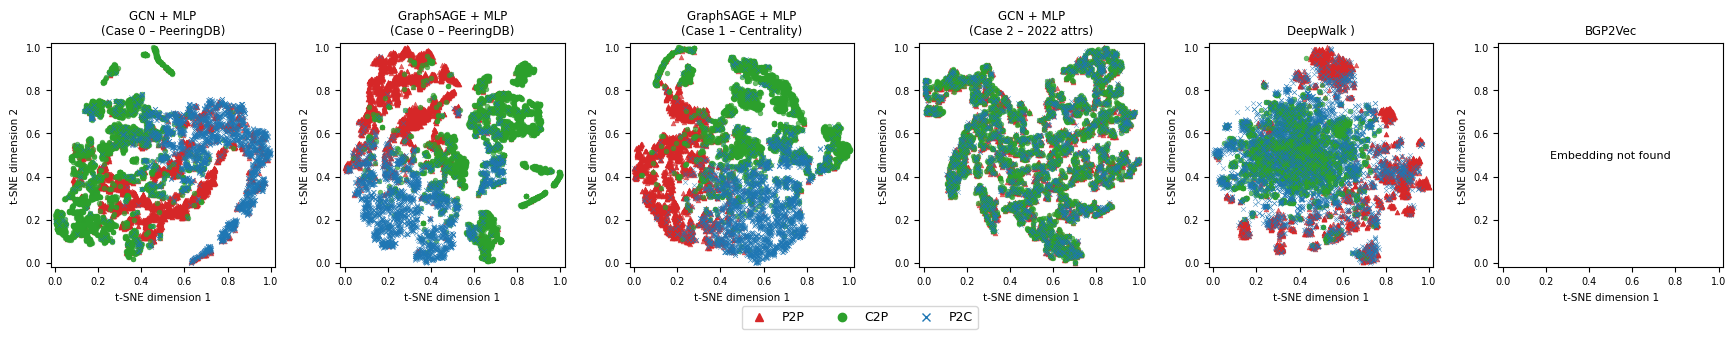

Saved to results/tsne_embeddings.pdf and .png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ── Style matching the paper figure ──────────────────────────
REL_STYLE = {
    'P2P': dict(color='#D62728', marker='^', label='P2P', s=12, alpha=0.7),
    'C2P': dict(color='#2CA02C', marker='o', label='C2P', s=12, alpha=0.7),
    'P2C': dict(color='#1F77B4', marker='x', label='P2C', s=12, alpha=0.7),
}
REL_ORDER = ['P2P', 'C2P', 'P2C']

n_panels = len(EXPERIMENTS)
fig, axes = plt.subplots(1, n_panels,
                         figsize=(3.6 * n_panels, 3.4),
                         constrained_layout=False)
fig.subplots_adjust(wspace=0.28, bottom=0.22)

for ax, (title, _), res in zip(axes, EXPERIMENTS, results):
    ax.set_title(title, fontsize=8.5, pad=6)
    ax.set_xlabel('t-SNE dimension 1', fontsize=7.5)
    ax.set_ylabel('t-SNE dimension 2', fontsize=7.5)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.tick_params(labelsize=7)
    ax.set_aspect('equal')

    if res is None:
        ax.text(0.5, 0.5, 'Embedding not found',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)
        continue

    proj, y = res
    for rel in REL_ORDER:
        mask = (y == rel)
        st   = REL_STYLE[rel]
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=st['color'], marker=st['marker'],
                   s=st['s'], alpha=st['alpha'], linewidths=0.4)

# Shared legend below all panels
legend_handles = [
    mlines.Line2D([], [], color=REL_STYLE[r]['color'],
                  marker=REL_STYLE[r]['marker'], linestyle='None',
                  markersize=6, label=r)
    for r in REL_ORDER
]
fig.legend(handles=legend_handles, loc='lower center',
           ncol=len(REL_ORDER), fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, 0.02))

out = Path('results/tsne_embeddings.pdf')
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, bbox_inches='tight', dpi=200)
plt.savefig(str(out).replace('.pdf','.png'), bbox_inches='tight', dpi=200)
plt.show()
print(f"Saved to {out} and .png")

In [ ]:
# ── Optional: vary N_SAMPLE or PERPLEXITY and replot ─────────
# Uncomment and re-run the cells above after changing these values:
# N_SAMPLE   = 5000
# PERPLEXITY = 30